/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [18:16:22] WARNING: /home/runner/work/pyodide-recipes/pyodide-recipes/packages/xgboost/build/xgboost-2.1.4/cpp_src/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9824561403508771
AUC-ROC: 0.9933862433862435

Classification Report:
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



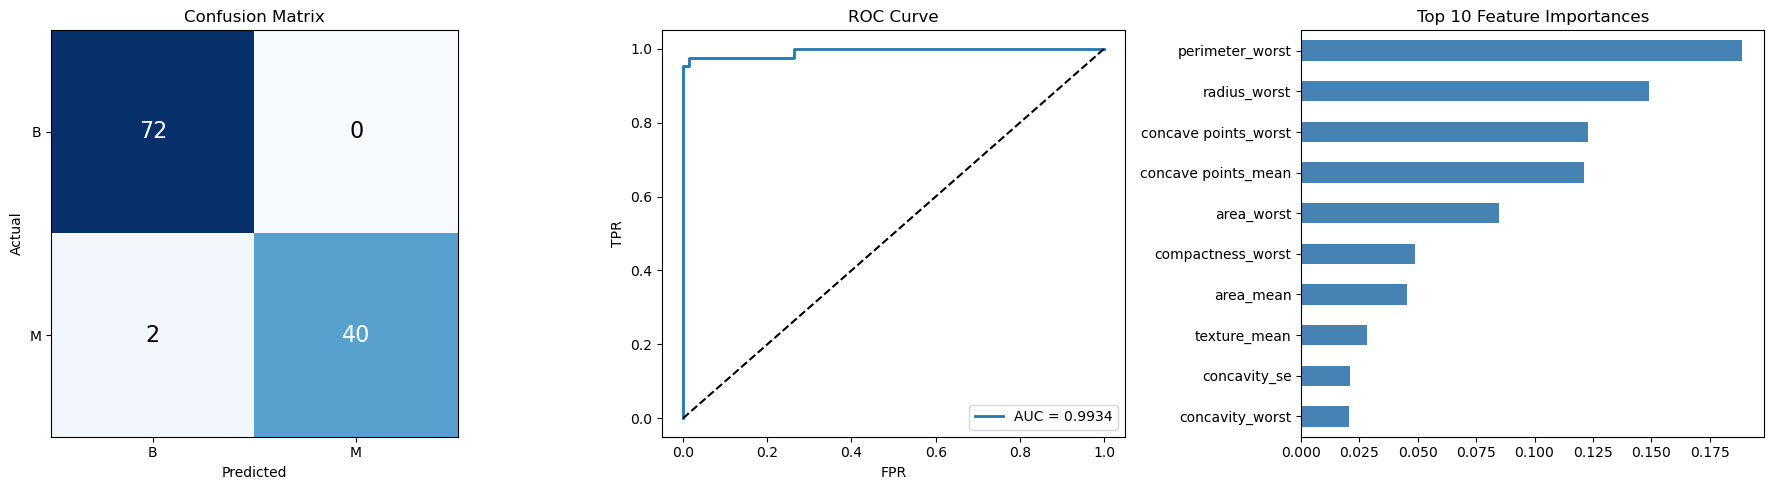

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Load & prep
df = pd.read_csv("data.csv")
df.columns = df.columns.str.strip().str.strip('"')
df = df.loc[:, ~df.columns.duplicated()]
if df.columns[-1] == '' or df.columns[-1].startswith('Unnamed'):
    df = df.iloc[:, :-1]

df.drop(columns=["id"], inplace=True)

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # M=1, B=0

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(le.classes_); axes[0].set_yticklabels(le.classes_)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                     color="white" if cm[i, j] > cm.max()/2 else "black")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc_score(y_test, y_proba):.4f}")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("ROC Curve"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].legend()

# Feature Importance (top 10)
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
importances.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Top 10 Feature Importances")

plt.tight_layout()
plt.show()